In [43]:
import numpy as np
from aniposelib.boards import CharucoBoard, Checkerboard
from aniposelib.cameras import Camera, CameraGroup
from aniposelib.utils import load_pose2d_fnames

In [46]:
vidnames = [['2026-07-11 17-58-46_A.mov'], 
    ['2026-07-11 17-58-46_B.mov'],
    ['2026-07-11 17-58-46_C.mov'],
    ['2026-07-11 17-58-46_D.mov'],
    ['2026-07-11 17-58-46_E.mov']]


cam_names = ['A', 'B', 'C', 'D', 'E']

n_cams = len(vidnames)

board = CharucoBoard(7, 10,
                     square_length=24,
                     marker_length=18,
                     marker_bits=4, dict_size=50)

cgroup = CameraGroup.from_names(cam_names, fisheye=False)

In [ ]:
# cgroup.calibrate_videos(vidnames, board)
# cgroup.dump('calibration.toml')

cgroup = CameraGroup.load('calibration.toml')

2026-07-11 17-58-46_A.mov


100%|████████████████████████████| 4074/4074 [00:31<00:00, 127.99it/s]


1355 boards detected
2026-07-11 17-58-46_B.mov


100%|█████████████████████████████| 4072/4072 [00:53<00:00, 76.17it/s]


2721 boards detected
2026-07-11 17-58-46_C.mov


...

3451 boards detected
2026-07-11 17-58-46_D.mov


100%|█████████████████████████████| 4074/4074 [00:48<00:00, 84.72it/s]


2360 boards detected
2026-07-11 17-58-46_E.mov


100%|████████████████████████████| 4076/4076 [00:25<00:00, 159.20it/s]


1048 boards detected
[{'name': 'A', 'size': [1920, 1080], 'matrix': [[1141.4731491966722, 0.0, 959.5], [0.0, 1141.4731491966722, 539.5], [0.0, 0.0, 1.0]], 'distortions': [0.0, 0.0, 0.0, 0.0, 0.0], 'rotation': [0.0, 0.0, 0.0], 'translation': [0.0, 0.0, 0.0]}, {'name': 'B', 'size': [1920, 1080], 'matrix': [[1135.82584825188, 0.0, 959.5], [0.0, 1135.82584825188, 539.5], [0.0, 0.0, 1.0]], 'distortions': [0.0, 0.0, 0.0, 0.0, 0.0], 'rotation': [0.0, 0.0, 0.0], 'translation': [0.0, 0.0, 0.0]}, {'name': 'C', 'size': [1920, 1080], 'matrix': [[1152.7589628471228, 0.0, 959.5], [0.0, 1152.7589628471228, 539.5], [0.0, 0.0, 1.0]], 'distortions': [0.0, 0.0, 0.0, 0.0, 0.0], 'rotation': [0.0, 0.0, 0.0], 'translation': [0.0, 0.0, 0.0]}, {'name': 'D', 'size': [1920, 1080], 'matrix': [[1189.7398415019984, 0.0, 959.5], [0.0, 1189.7398415019984, 539.5], [0.0, 0.0, 1.0]], 'distortions': [0.0, 0.0, 0.0, 0.0, 0.0], 'rotation': [0.0, 0.0, 0.0], 'translation': [0.0, 0.0, 0.0]}, {'name': 'E', 'size': [1920, 1080]

In [48]:
fname_dict = {
    'A': '2026-07-11 18-14-24_A_keypoints.h5',
    'B': '2026-07-11 18-14-24_B_keypoints.h5',
    'C': '2026-07-11 18-14-24_C_keypoints.h5',
    'D': '2026-07-11 18-14-24_D_keypoints.h5',
    'E': '2026-07-11 18-14-24_E_keypoints.h5',
}

d = load_pose2d_fnames(fname_dict, cam_names=cgroup.get_names())

score_threshold = 0.5

n_cams, n_points, n_joints, _ = d['points'].shape
points = d['points']
scores = d['scores']

bodyparts = d['bodyparts']

# remove points that are below threshold
points[scores < score_threshold] = np.nan

points_flat = points.reshape(n_cams, -1, 2)
scores_flat = scores.reshape(n_cams, -1)

p3ds_flat = cgroup.triangulate(points_flat, progress=True)
reprojerr_flat = cgroup.reprojection_error(p3ds_flat, points_flat, mean=True)

p3ds = p3ds_flat.reshape(n_points, n_joints, 3)
reprojerr = reprojerr_flat.reshape(n_points, n_joints)

Text(0.5, 1.0, 'x, y, z coordinates of wrist')

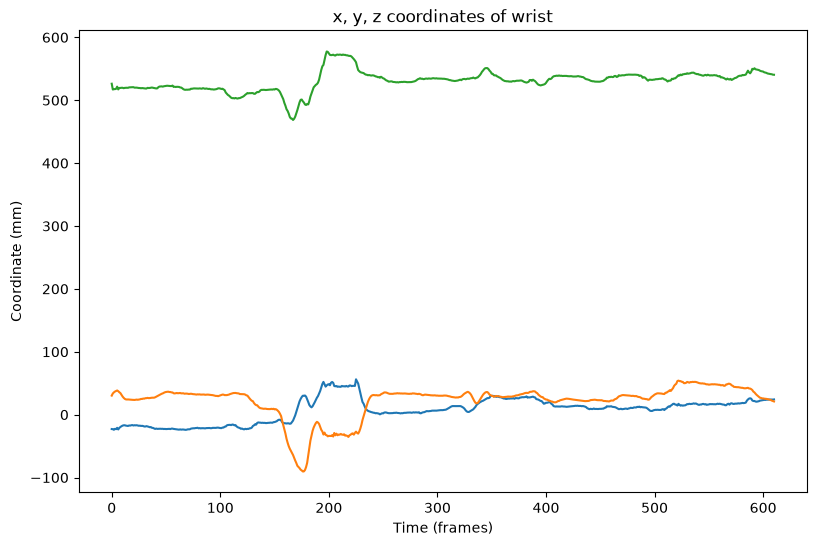

In [49]:
# plot the x, y, z coordinates of joint 0

import matplotlib.pyplot as plt

plt.figure(figsize=(9.4, 6))
plt.plot(p3ds[:, 0, 0])
plt.plot(p3ds[:, 0, 1])
plt.plot(p3ds[:, 0, 2])
plt.xlabel("Time (frames)")
plt.ylabel("Coordinate (mm)")
plt.title("x, y, z coordinates of {}".format(bodyparts[0]))

[[<mpl_toolkits.mplot3d.art3d.Line3D at 0x137d79a90>],

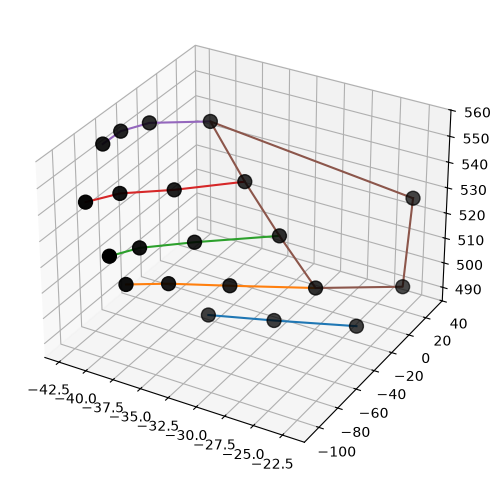

In [50]:
## plot the first frame in 3D
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.pyplot import get_cmap

def connect(ax, points, bps, bp_dict, color):
    ixs = [bp_dict[bp] for bp in bps]
    return ax.plot(points[ixs, 0], points[ixs, 1], points[ixs, 2], color=color)

def connect_all(ax, points, scheme, bodyparts, cmap=None):
    if cmap is None:
        cmap = get_cmap('tab10')
    bp_dict = dict(zip(bodyparts, range(len(bodyparts))))
    lines = []
    for i, bps in enumerate(scheme):
        line = connect(ax, points, bps, bp_dict, color=cmap(i)[:3])
        lines.append(line)
    return lines

## scheme for the hand
scheme = [
    ["thumb_mcp", "thumb_ip", "thumb_tip"],
    ["index_finger_mcp", "index_finger_pip", "index_finger_dip", "index_finger_tip"],
    ["middle_finger_mcp", "middle_finger_pip", "middle_finger_dip", "middle_finger_tip"],
    ["ring_finger_mcp", "ring_finger_pip", "ring_finger_dip", "ring_finger_tip"],
    ["pinky_mcp", "pinky_pip", "pinky_dip", "pinky_tip"],
    ["wrist", "thumb_cmc", "index_finger_mcp", "middle_finger_mcp",
     "ring_finger_mcp", "pinky_mcp", "wrist"],
]

framenum = 0
p3d = p3ds[framenum]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(p3d[:,0], p3d[:,1], p3d[:,2], c='black', s=100)
connect_all(ax, p3d, scheme, bodyparts)